<a href="https://colab.research.google.com/github/renabasheer0411-ux/Churn-Prediction/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# Import necessary libraries
import os
import json
import joblib
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [33]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Standardize numerical features and convert categorical labels into numbers
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression

# Import Random Forest and Gradient Boosting classification algorithms
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Import evaluation metrics to measure model performance
from sklearn.metrics import (
    accuracy_score,       # Percentage of correct predictions
    precision_score,      # Measures how many predicted positives are actually positive
    recall_score,         # Measures how many actual positives are correctly identified
    f1_score,             # Harmonic mean of precision and recall
    roc_auc_score,        # Measures the model's ability to distinguish between classes
    roc_curve,            # Calculates values for plotting the ROC curve
    confusion_matrix,     # Shows correct and incorrect predictions by class
    classification_report # Provides precision, recall, F1-score and support
)

In [34]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/churn-prediction.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

 1. Load & clean

In [36]:
df = pd.read_csv('/content/drive/MyDrive/telco_churn.csv')

# TotalCharges has blank strings for new customers (tenure=0) -> coerce & fill
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)
print(df)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

2. EDA

Overall churn rate: 26.5%


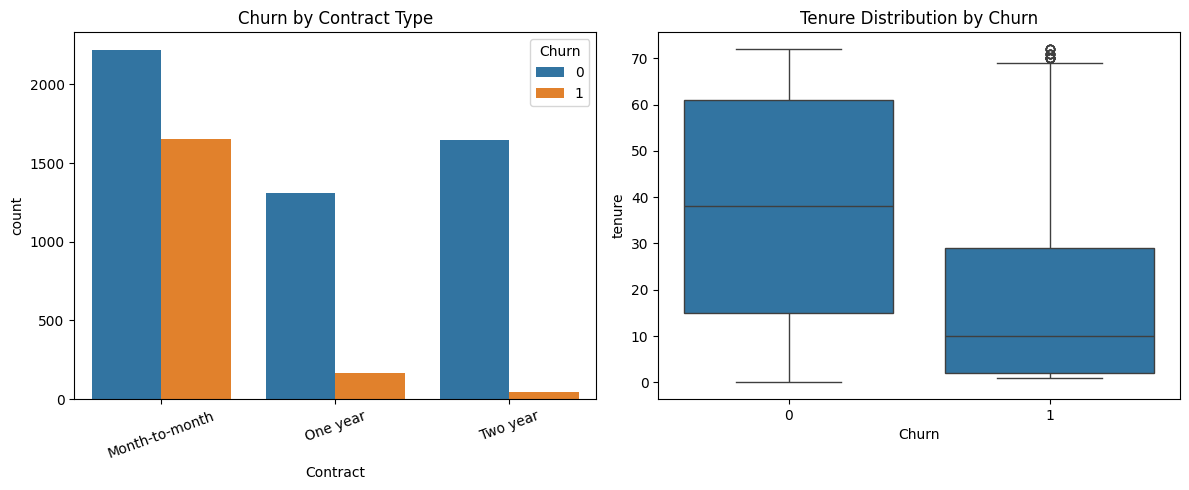

In [92]:
OUTPUT_DIR="."
def run_eda(df: pd.DataFrame):
    churn_rate = df["Churn"].mean() * 100
    print(f"Overall churn rate: {churn_rate:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0])
    axes[0].set_title("Churn by Contract Type")
    axes[0].tick_params(axis="x", rotation=20)

    sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[1])
    axes[1].set_title("Tenure Distribution by Churn")

    plt.tight_layout()
    plt.show()

    return churn_rate

churn_rate=run_eda(df)

3. Feature engineering

In [46]:
def prepare_features(df: pd.DataFrame):
    df = df.copy()

    binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
    for col in binary_cols:
        df[col] = df[col].map({"Yes": 1, "No": 0})

    df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

    # Simple engineered feature: average monthly spend vs tenure
    df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

    categorical_cols = df.select_dtypes(include="object").columns.tolist()
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    X = df.drop(columns=["Churn"])
    y = df["Churn"]
    return X, y

X, Y = prepare_features(df)
print(X.head())
print(Y.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  AvgMonthlySpend  ...  \
0                 1           29.85         29.85        29.850000  ...   
1                 0           56.95       1889.50        55.573529  ...   
2                 1           53.85        108.15        54.075000  ...   
3                 0           42.30       1840.75        40.905556  ...   
4                 1           70.70        151.65        75.825000  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            Fals

4. Train & compare models

In [59]:
RANDOM_STATE=42
def train_models(X_train, Y_train):
    models = {
        "LogisticRegression": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
    }
    for model in models.values():
        model.fit(X_train, Y_train)
    return models

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
models=train_models(X_train,Y_train)
print(models)

{'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42), 'RandomForest': RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42), 'GradientBoosting': GradientBoostingClassifier(random_state=42)}


In [60]:
def evaluate_models(models, X_test, y_test):
    results = {}
    for name, model in models.items():
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]
        results[name] = {
            "accuracy": round(accuracy_score(y_test, preds), 3),
            "precision": round(precision_score(y_test, preds), 3),
            "recall": round(recall_score(y_test, preds), 3),
            "f1": round(f1_score(y_test, preds), 3),
            "roc_auc": round(roc_auc_score(y_test, proba), 3),
        }
    return results

results = evaluate_models(models, X_test, Y_test)
print(results)

{'LogisticRegression': {'accuracy': 0.74, 'precision': 0.507, 'recall': 0.783, 'f1': 0.616, 'roc_auc': np.float64(0.842)}, 'RandomForest': {'accuracy': 0.785, 'precision': 0.622, 'recall': 0.484, 'f1': 0.544, 'roc_auc': np.float64(0.828)}, 'GradientBoosting': {'accuracy': 0.803, 'precision': 0.668, 'recall': 0.516, 'f1': 0.582, 'roc_auc': np.float64(0.842)}}


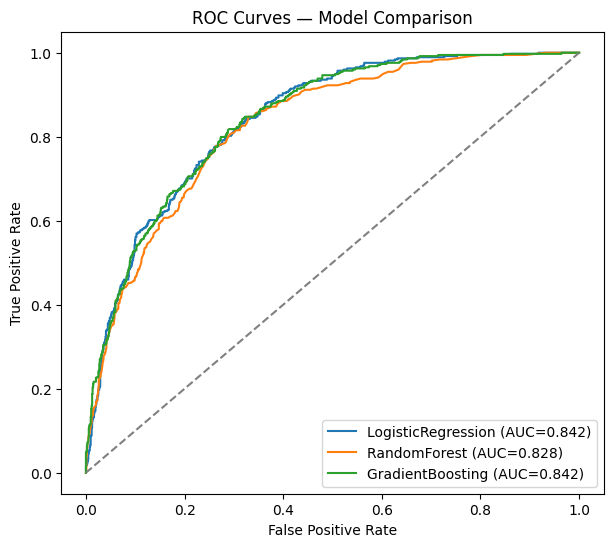

In [78]:
def plot_roc_curves(models, X_test, Y_test):
    plt.figure(figsize=(7, 6))
    for name, model in models.items():
        proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(Y_test, proba)
        auc = roc_auc_score(Y_test, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves — Model Comparison")
    plt.legend()
    plt.show()


plot_roc_curves(models, X_test, Y_test)



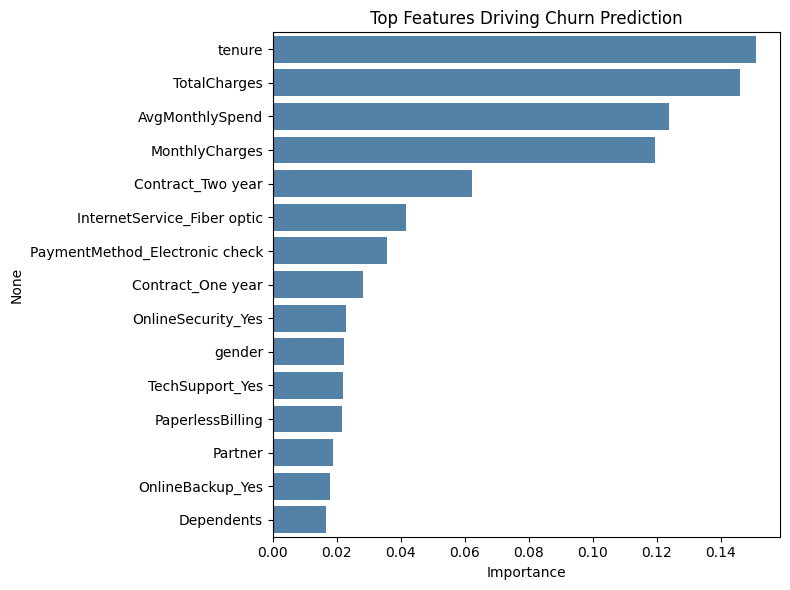

In [89]:
def plot_feature_importance(model, feature_names, top_n=15):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top_features = importances.sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, color="steelblue")
    plt.title("Top Features Driving Churn Prediction")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importance(models["RandomForest"], X_train.columns, top_n=15)


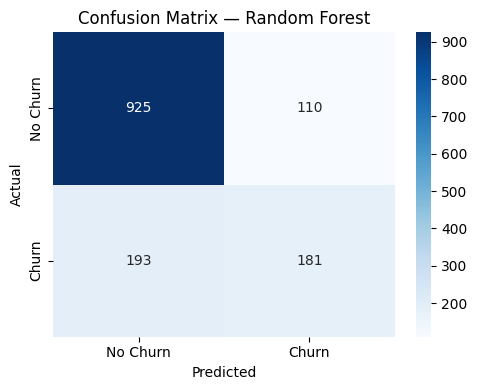

In [90]:
def plot_confusion_matrix(model, X_test, y_test, name):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(models["RandomForest"], X_test, Y_test, "Random Forest")